<a href="https://colab.research.google.com/github/Mohammed-Taher6705/jigsaw-puzzle-matching/blob/main/Enhancing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Mohammed-Taher6705/jigsaw-puzzle-matching.git

Cloning into 'jigsaw-puzzle-matching'...
remote: Enumerating objects: 1337, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 1337 (delta 14), reused 13 (delta 13), pack-reused 1322 (from 4)
Receiving objects: 100% (1337/1337), 386.69 MiB | 38.61 MiB/s, done.
Resolving deltas: 100% (92/92), done.


In [ ]:
import zipfile
import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import shutil

In [ ]:
zip_path = "/content/jigsaw-puzzle-matching/denoised_dataset.zip"
extract_path = "/content"


os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extracted to:", extract_path)
print("Contents:", os.listdir(extract_path))



Extracted to: /content
Contents: ['.config', 'denoised_dataset', 'jigsaw-puzzle-matching', 'sample_data']


In [ ]:
# Edge Enhancement

input_folder = "/content/denoised_dataset"
output_folder = "/content/enhanced_dataset"
os.makedirs(output_folder, exist_ok=True)


def enhance_edges(img):
    """Apply CLAHE + Unsharp Mask and return final enhanced output."""

    # Local contrast enhancement
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    L_clahe = clahe.apply(L)

    lab_clahe = cv2.merge([L_clahe, A, B])
    clahe_img = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    #Edge sharpening (Unsharp Mask)

    blur = cv2.GaussianBlur(clahe_img, (5,5), 1.5)

    alpha = 1.8  # sharpening strength
    img_sharp = cv2.addWeighted(clahe_img, 1 + alpha, blur, -alpha, 0)

    return img_sharp



image_paths = sorted(
    glob(os.path.join(input_folder, "**", "*.jpg"), recursive=True) +
    glob(os.path.join(input_folder, "**", "*.png"), recursive=True)
)
print(f"Enhancing {len(image_paths)} images...")


for img_path in image_paths:


    img = cv2.imread(img_path, cv2.IMREAD_COLOR)


    enhanced_img = enhance_edges(img)


    relative_path = os.path.relpath(img_path, input_folder)
    out_path = os.path.join(output_folder, relative_path)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)


    cv2.imwrite(out_path, enhanced_img)


print("\nEnhanced images stored in:")
print(output_folder)


Enhancing 440 images...

Enhanced images stored in:
/content/enhanced_dataset


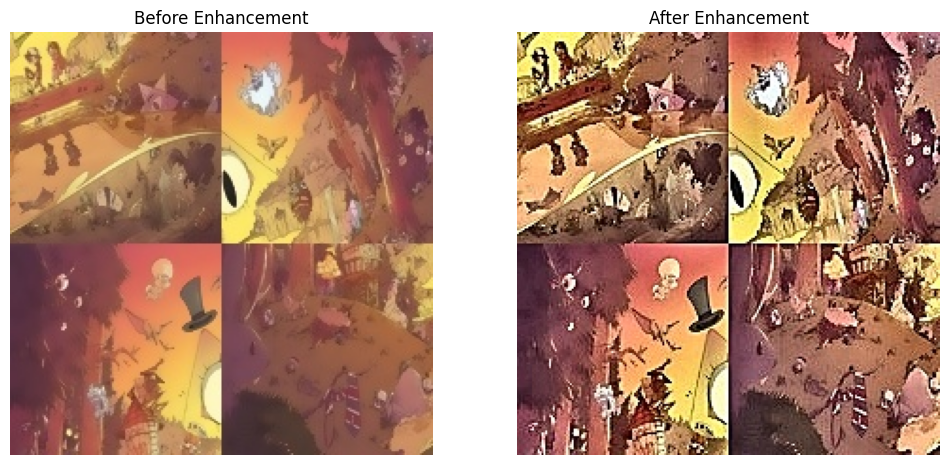

In [ ]:
orig_path ="/content/denoised_dataset/puzzle_2x2/2.jpg"
enh_path  = "/content/enhanced_dataset/puzzle_2x2/2.jpg"


orig = cv2.imread(orig_path)
enh  = cv2.imread(enh_path)
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
enh  = cv2.cvtColor(enh,  cv2.COLOR_BGR2RGB)


plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Before Enhancement")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(enh)
plt.title("After Enhancement")
plt.axis('off')

plt.show()







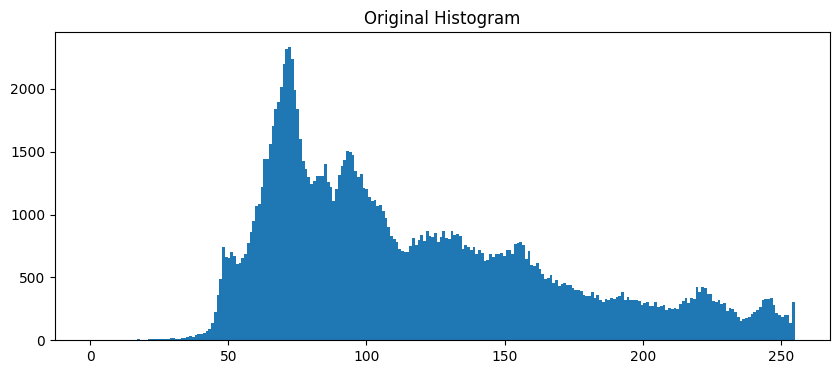

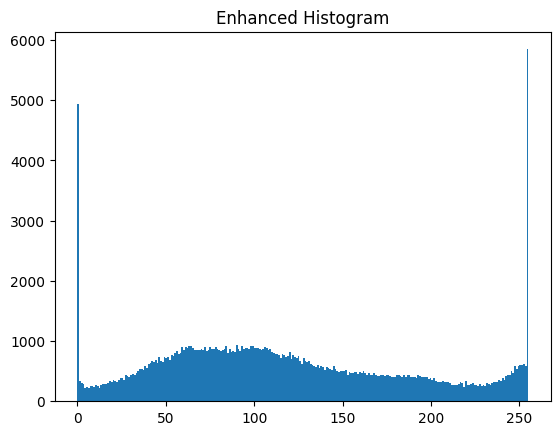

In [ ]:
plt.figure(figsize=(10,4))

plt.hist(orig.ravel(), bins=256)
plt.title("Original Histogram")
plt.show()

plt.hist(enh.ravel(), bins=256)
plt.title("Enhanced Histogram")
plt.show()


In [ ]:
input_dir = "/content/enhanced_dataset"
output_zip = "/content/enhanced_dataset"

shutil.make_archive(
    base_name=output_zip,
    format="zip",
    root_dir=os.path.dirname(input_dir),
    base_dir=os.path.basename(input_dir)
)


'/content/enhanced_dataset.zip'